In [6]:
import glob
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Path to Template folder
template_folder = "Template"

# Get all tif files
template_tifs = glob.glob(os.path.join(template_folder, "*.tif"))

for path in template_tifs:

    print(path)

Template/water_weighted_template.tif
Template/peatland_weighted_template.tif
Template/Slope_weighted_template.tif
Template/canopy_weighted_template.tif
Template/superdeposits_weighted_template.tif
Template/roads_weighted_template.tif
Template/dtw_weighted_template.tif


In [11]:
stacked_arrays = []
meta = None

for f in template_tifs:
    
    with rasterio.open(f) as src:
        
        arr = src.read(1).astype("float32")

        # Replace nodata with NaN
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

        stacked_arrays.append(arr)

        if meta is None:
            meta = src.meta.copy()

stacked_arrays = np.array(stacked_arrays)

print("Stack shape:", stacked_arrays.shape)

Stack shape: (7, 10520, 8194)


In [12]:
# If already normalized & weighted:
cost_layer = np.nansum(stacked_arrays, axis=0)

# Optional: prevent zero-cost cells
cost_layer[cost_layer <= 0] = 0.001

print("\nCost layer stats:")
print("Min:", np.nanmin(cost_layer))
print("Max:", np.nanmax(cost_layer))
print("Mean:", np.nanmean(cost_layer))


Cost layer stats:
Min: 5.6069043e-09
Max: 1.0739284
Mean: 0.30120218


In [13]:
meta.update(dtype="float32", nodata=np.nan)

output_path = os.path.join('CostLayer', "Cost_Layer.tif")

with rasterio.open(output_path, "w", **meta) as dst:
    dst.write(cost_layer.astype("float32"), 1)

print("\nCost layer saved at:", output_path)



Cost layer saved at: CostLayer/Cost_Layer.tif


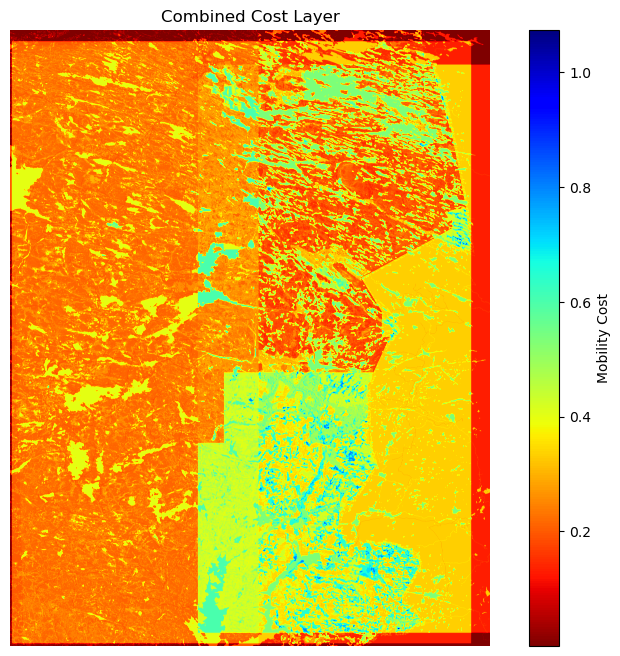

In [18]:
plt.figure(figsize=(10,8))
plt.imshow(cost_layer, cmap="jet_r")
plt.colorbar(label="Mobility Cost")
plt.title("Combined Cost Layer")
plt.axis('off')
plt.show()

In [28]:
# threshold = np.nanpercentile(cost_layer, 20)

# print("40% cost threshold:", threshold)


In [29]:
# good_mobility = np.where(cost_layer <= threshold, 1, np.nan)

In [30]:
# plt.figure(figsize=(10,8))
# plt.imshow(good_mobility, cmap="jet_r")
# plt.title("Top 40% Best Mobility Areas")
# plt.axis("off")
# plt.show()